# Airbnb en Nueva York
Una empresa ha recolectado la información del alquiler de viviendas en Nueva York a través de la aplicación Airbnb durante el año 2019. Este conjunto de datos se utilizó para entrenar modelos de Machine Learning durante ese año, en una competición en abierto.

Ahora lo utilizaremos para llevar a cabo un estudio acerca de las variables que componen el dataset a fin de comprenderlo y obtener conclusiones sobre él.

#### Paso 1: Carga del conjunto de datos
    Puedes descargar el conjunto de datos directamente desde Kaggle.com o en el siguiente enlace: https://breathecode.herokuapp.com/asset/internal-link?id=927&path=AB_NYC_2019.csv. Almacena los datos en crudo en la carpeta ./data/raw.

#### Paso 2: Realiza un EDA completo
    Este paso es vital para asegurar que nos quedamos con las variables estrictamente necesarias y eliminamos las que no son relevantes o no aportan información. Utiliza el Notebook de ejemplo que trabajamos y adáptalo a este caso de uso.

        Asegúrate de dividir convenientemente el conjunto de datos en train y test como hemos visto en la lección.

#### Paso 3: Guarda el conjunto de datos procesado
    Después del EDA puedes guardar los datos en la carpeta ./data/processed. Asegúrate de agregar la carpeta de los datos en el .gitignore. Los datos al igual que los modelos no se deben subir a git.

In [2]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

In [3]:
total_data = pd.read_csv("../data/raw/AB_NYC_2019.csv")


Se carga el conjunto de datos correspondiente a los alojamientos publicados en Airbnb en la ciudad de Nueva York durante el año 2019.

In [4]:
total_data.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

In [5]:
total_data.shape

(48895, 16)

In [6]:
total_data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


El dataset contiene información relacionada con identificadores de propiedades, anfitriones, ubicación geográfica, tipo de alojamiento, precio y variables asociadas a reseñas de usuarios.

In [7]:
total_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

Se identifican valores faltantes principalmente en variables relacionadas con reseñas de usuarios, mientras que las variables estructurales del alojamiento presentan alta completitud.

In [8]:
total_data.dtypes.value_counts()

int64      7
str        6
float64    3
Name: count, dtype: int64

In [9]:
total_data.select_dtypes(include=['object']).columns

C:\Users\nata1\AppData\Local\Temp\ipykernel_31248\745359477.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  total_data.select_dtypes(include=['object']).columns


Index(['name', 'host_name', 'neighbourhood_group', 'neighbourhood',
       'room_type', 'last_review'],
      dtype='str')

In [10]:
total_data.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


La variable precio presenta una alta dispersión y valores máximos elevados, lo que nos podria sugerir la presencia de valores extremos.

In [11]:
total_data.isna().sum().sum()

np.int64(20141)

In [12]:
total_data.isna().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [13]:
(total_data.isna().sum() / len(total_data) * 100).sort_values(ascending=False)

last_review                       20.558339
reviews_per_month                 20.558339
host_name                          0.042949
name                               0.032723
neighbourhood_group                0.000000
neighbourhood                      0.000000
id                                 0.000000
host_id                            0.000000
longitude                          0.000000
latitude                           0.000000
room_type                          0.000000
price                              0.000000
number_of_reviews                  0.000000
minimum_nights                     0.000000
calculated_host_listings_count     0.000000
availability_365                   0.000000
dtype: float64

Text(0, 0.5, 'Sample Number')

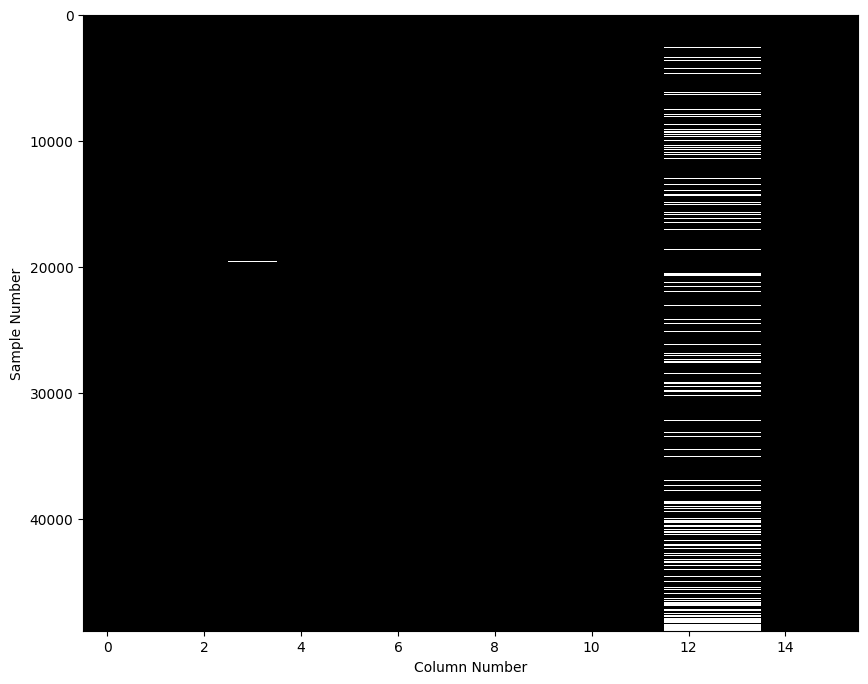

In [14]:
plt.figure(figsize=(10, 8))
plt.imshow(total_data.isna(), aspect="auto", interpolation="nearest", cmap="gray")
plt.xlabel("Column Number")
plt.ylabel("Sample Number")

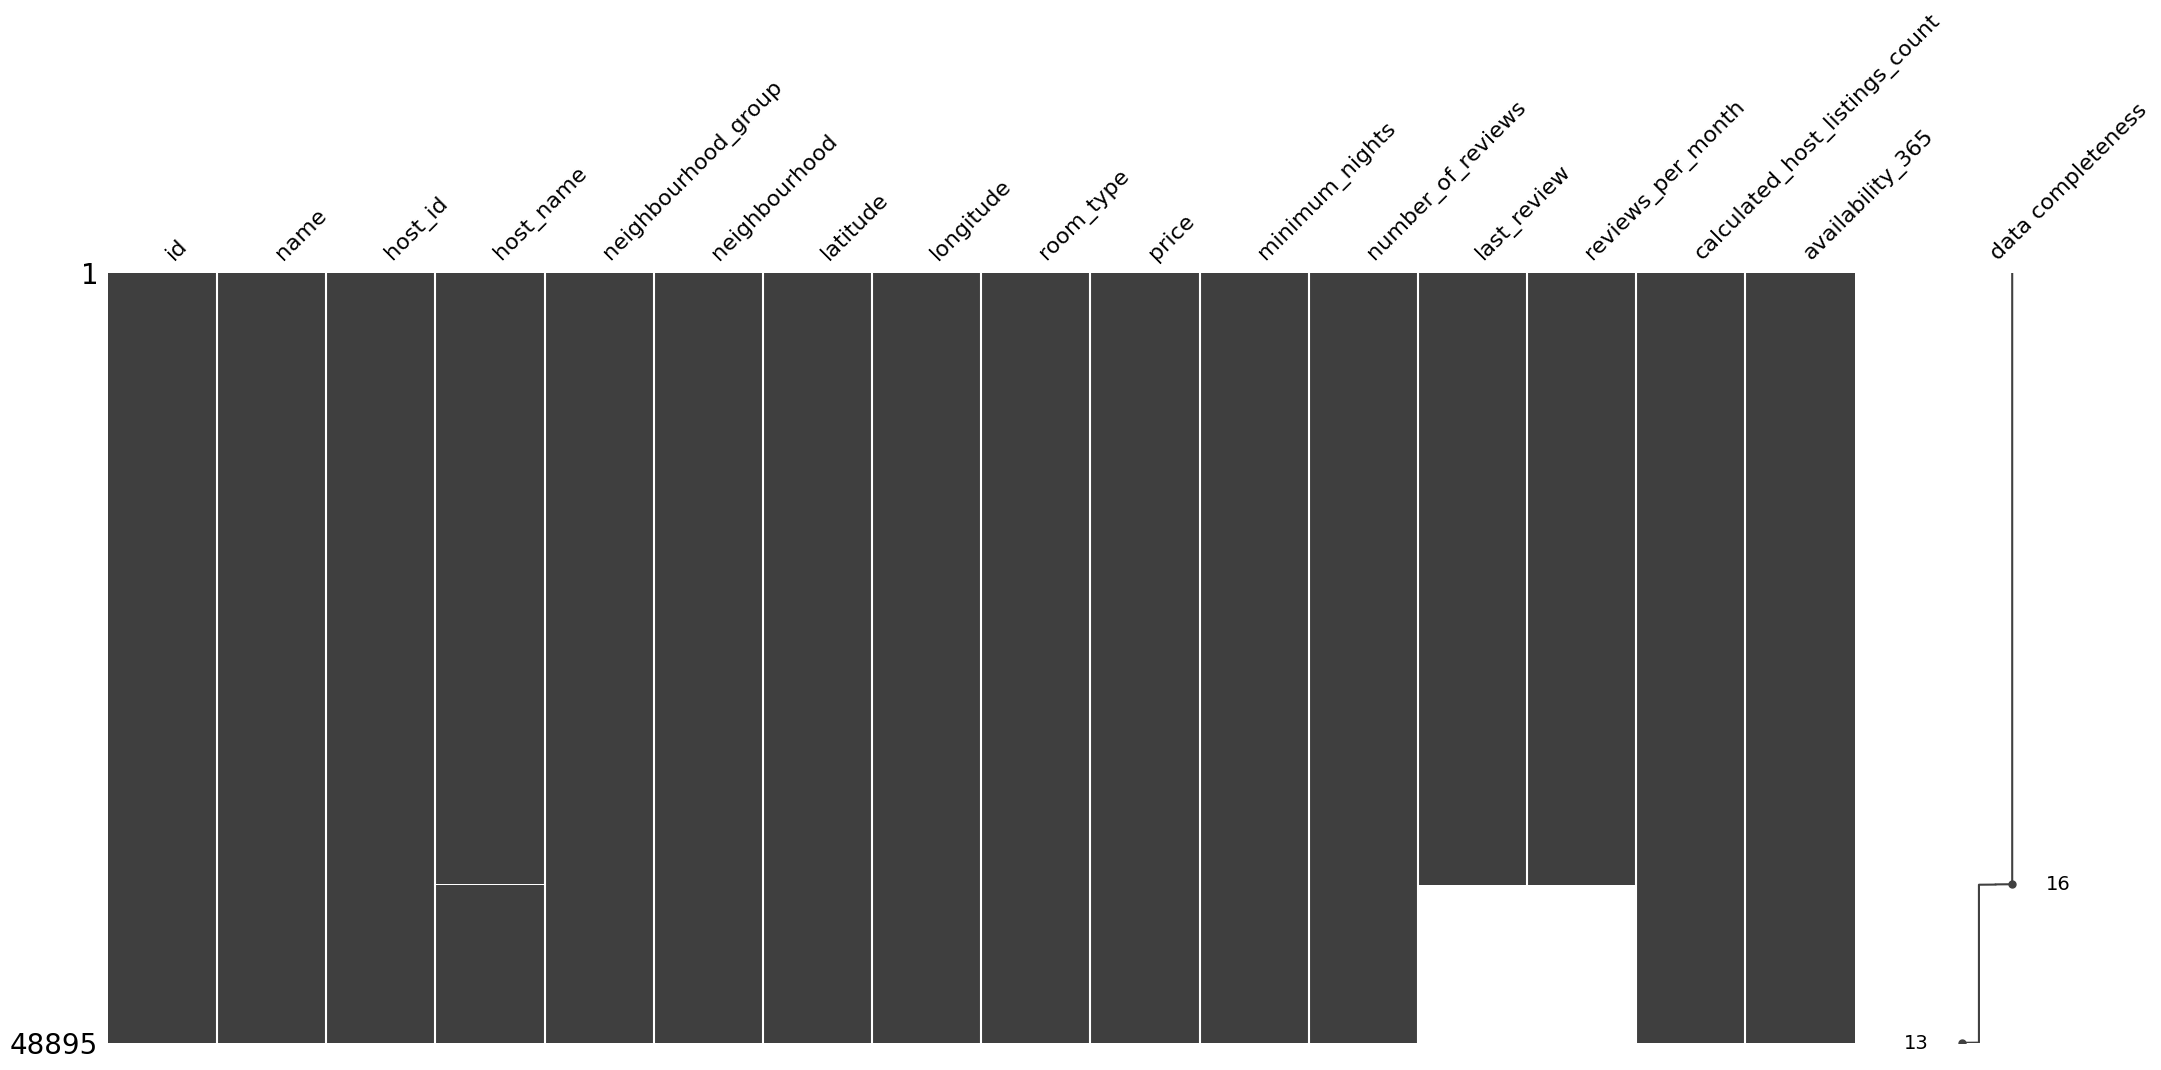

In [15]:
msno.matrix(total_data, labels=True, sort="descending");

<Axes: >

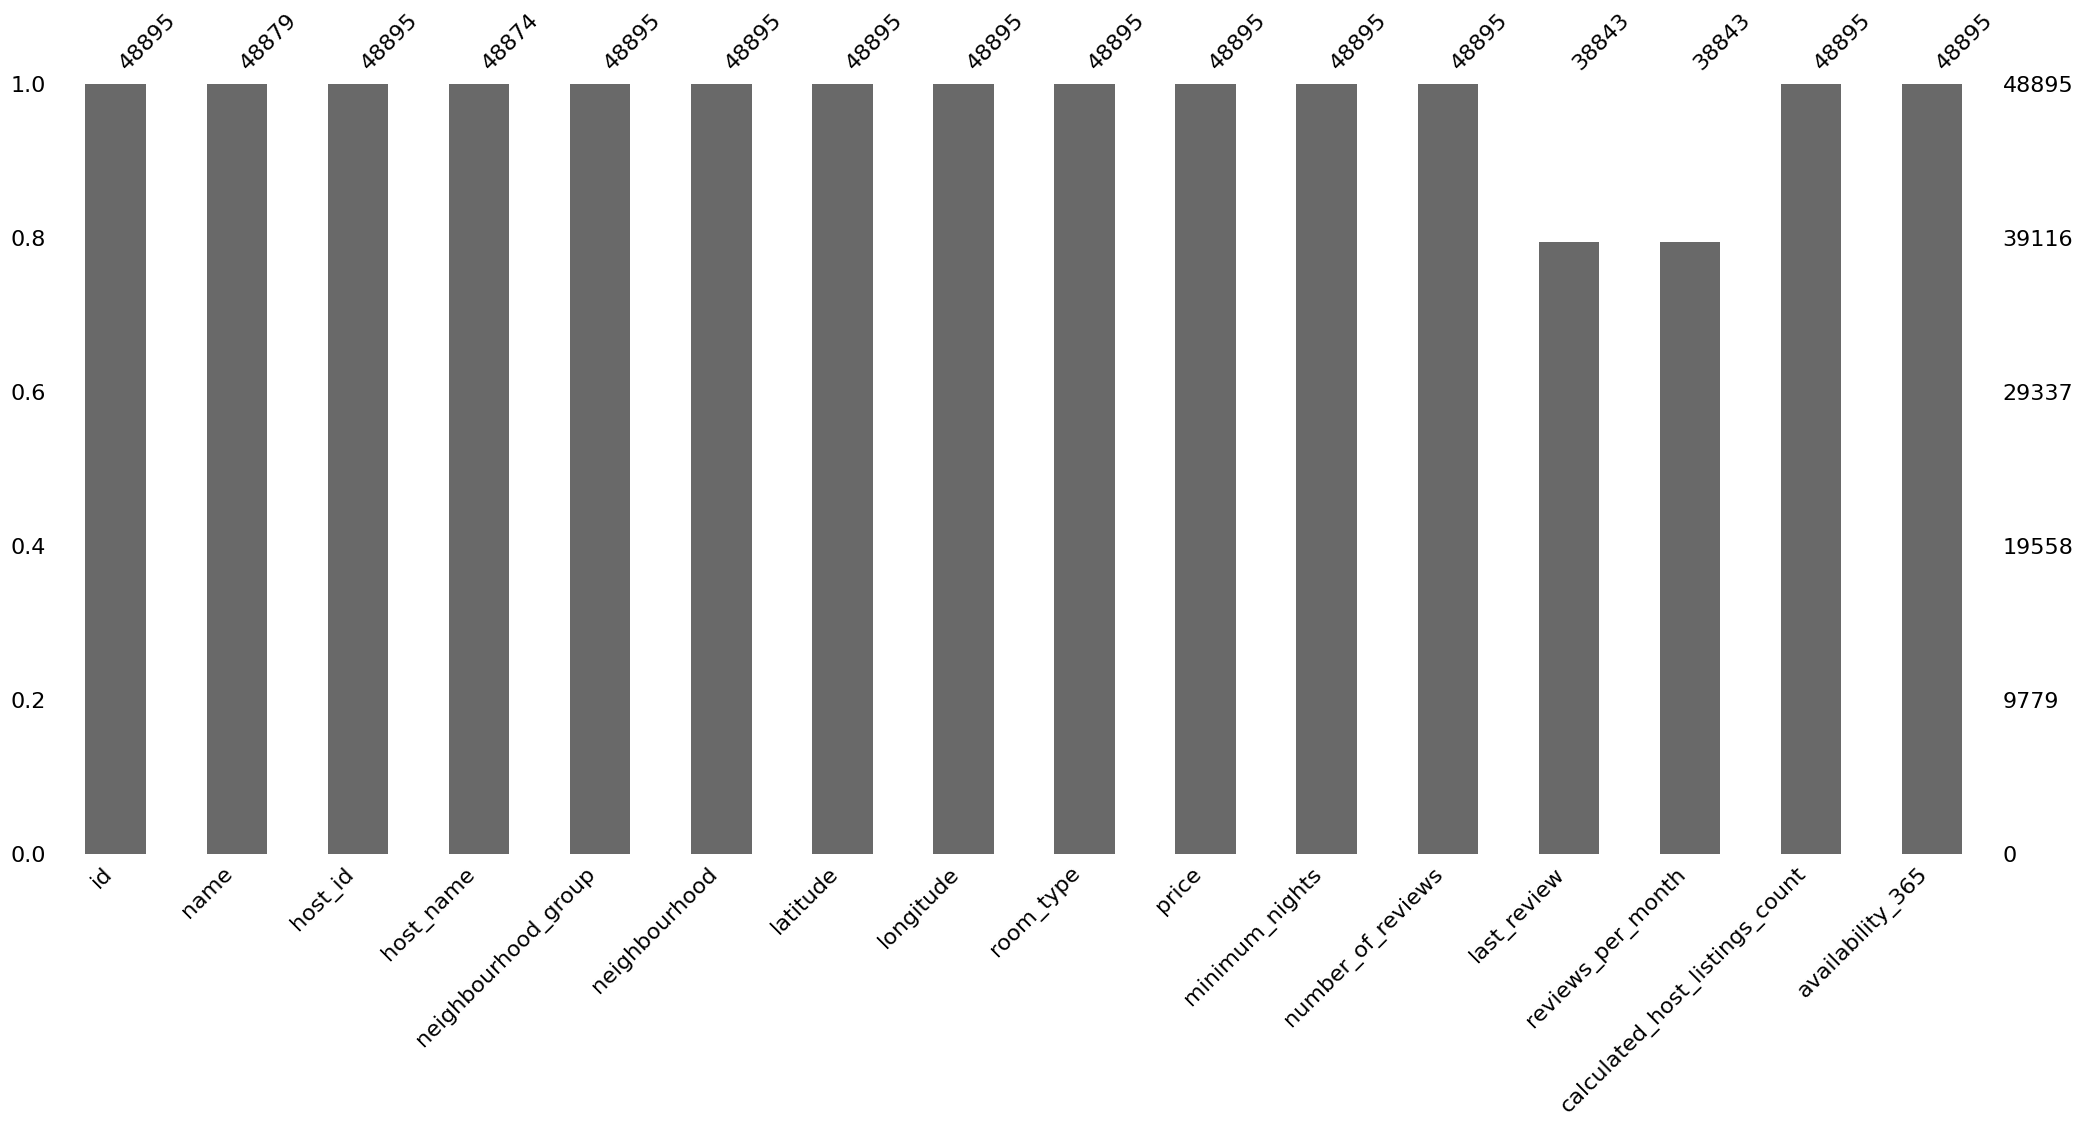

In [16]:
msno.bar(total_data)

La mayoría de columnas no presentan datos nulos, como lo es id, host_id, latitude, longitude, price, availability_365.

Hay muchos registros sin datos en last_review, reviews_per_month, una raón lógica podria ser que la propiedad no ha recibido reseñas por lo que no es un error.

No se observan pérdidas masivas de información en variables críticas.


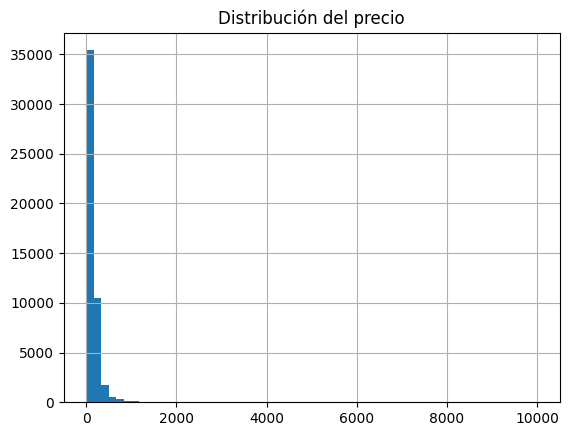

In [17]:
total_data["price"].hist(bins=60)
plt.title("Distribución del precio")
plt.show()

La mayoría de alojamientos presentan precios bajos o moderados, observándose valores extremos que podrían afectar el análisis estadístico.

In [18]:
total_data["room_type"].value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

El tipo de alojamiento más ofertado son viviendas completas, por lo que podriamos sugerir que hay una mayor demanda de privacidad por parte de los usuarios.

In [19]:
total_data["neighbourhood_group"].value_counts()

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

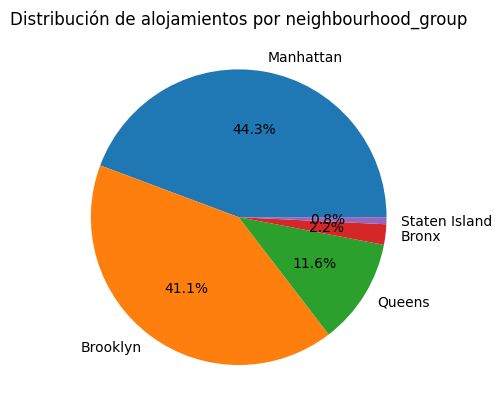

In [20]:
porcentaje = total_data["neighbourhood_group"].value_counts(normalize=True) * 100
porcentaje.plot(kind="pie", autopct="%1.1f%%")

plt.title("Distribución de alojamientos por neighbourhood_group")
plt.ylabel("")

plt.show()

La mayoría de los alojamientos se concentran en Manhattan que representa el 44.3% y Brooklyn que es el 41.1%, por lo que juntos representan aproximadamente el 85% del dataset, mientras que los otros distritos tienen una participación mucho menor.

In [21]:
total_data.groupby("neighbourhood_group")["price"].mean().sort_values()

neighbourhood_group
Bronx             87.496792
Queens            99.517649
Staten Island    114.812332
Brooklyn         124.383207
Manhattan        196.875814
Name: price, dtype: float64

El distrito con el precio promedio más bajo es el Bronx, por lo que podemos deducir una menor demanda turística o menor nivel de exclusividad.

Por el contrario Manhattan presenta el precio promedio más alto, siendo casi del doble que algunos de los otros distritos, lo cual tiene sentido tenido en cuenta su alta concentración de alojamientos y su atractivo turístico.

Brooklyn y Staten Island cuentan con precios intermedios, mientras que Queens se mantiene en un rango económico.

Quiere decir que nos sugiere que el precio está relacionado con la popularidad y ubicación del distrito dentro de la ciudad

In [22]:
total_data["reviews_per_month"] = total_data["reviews_per_month"].fillna(0)

Se reemplazan los valores faltantes (NaN) por 0, ya que se asume que los alojamientos sin información registrada no han recibido reseñas recientemente.

In [23]:
reviews_zone = total_data.groupby("neighbourhood_group")["reviews_per_month"].mean().sort_values()

reviews_zone

neighbourhood_group
Manhattan        0.976782
Brooklyn         1.049790
Bronx            1.475655
Queens           1.567076
Staten Island    1.576381
Name: reviews_per_month, dtype: float64

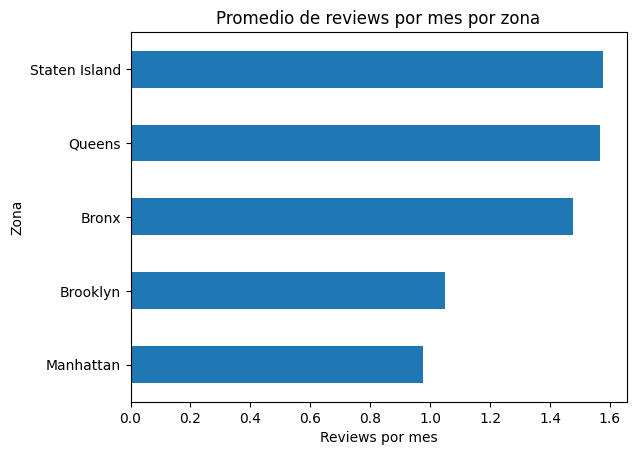

In [24]:
reviews_zone.plot(kind="barh")

plt.title("Promedio de reviews por mes por zona")
plt.xlabel("Reviews por mes")
plt.ylabel("Zona")

plt.show()

Las zonas con mayor promedio de reseñas por mes presentan mayor rotación de huéspedes, lo que puede indicar precios más accesibles, alta demanda o alojamientos más activos en la plataforma. Según lo visto anteriormente se sabe que Staten Island cuenta con precios intermedios y que Queens se mantiene en un rango económico.

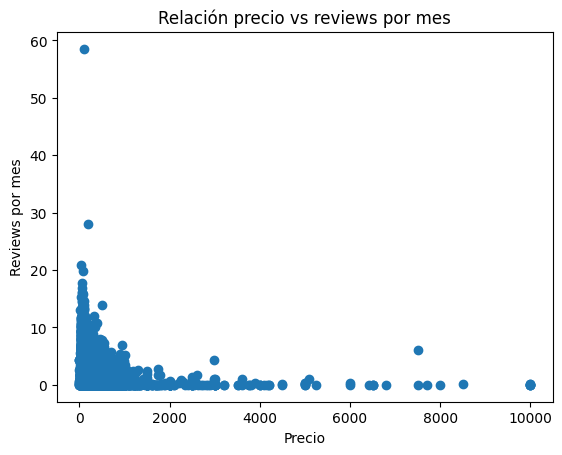

In [25]:
plt.scatter(total_data["price"], total_data["reviews_per_month"])

plt.title("Relación precio vs reviews por mes")
plt.xlabel("Precio")
plt.ylabel("Reviews por mes")

plt.show()

Se observa que los alojamientos con precios más bajos tienden a tener más reviews, lo que sugiere mayor ocupación.

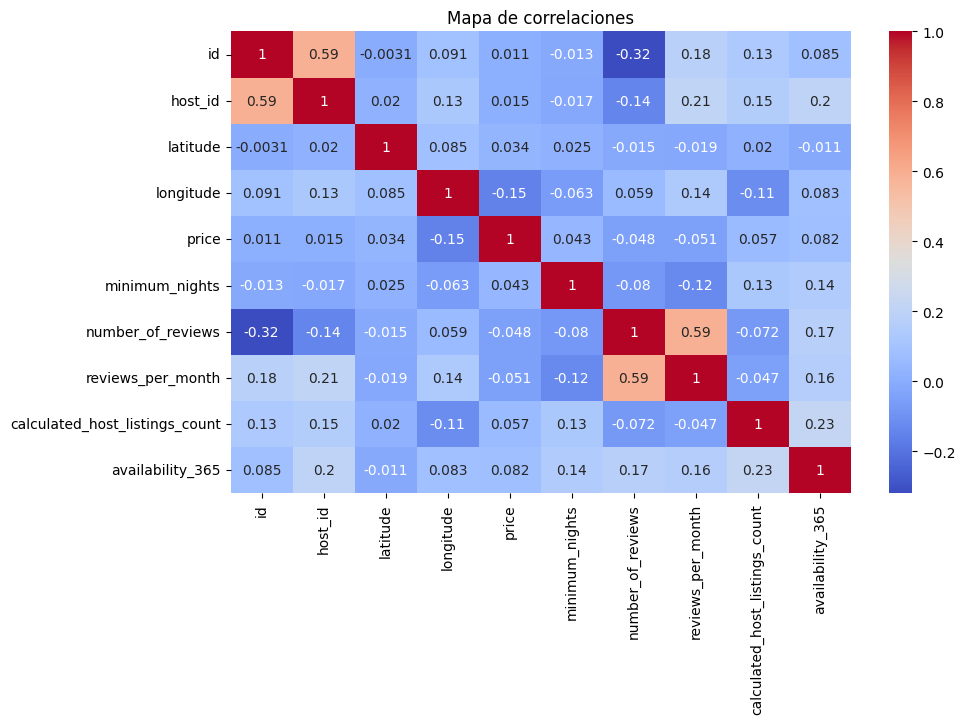

In [26]:
import seaborn as sns

corr = total_data.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Mapa de correlaciones")

plt.show()

Se puede concluir que:

- Existe una relación positiva moderada entre el número de reviews y los reviews por mes, lo cual es lógico, ya que los alojamientos con mayor actividad suelen tiener más reseñas en el tiempo.

- La variable precio presenta correlaciones bajas o débiles con la mayoría de variables, lo que nos miestra que el valor de un alojamiento no depende únicamente de un solo factor, sino de múltiples características como la ubicación, el tipo de habitación o la disponibilidad.

- También se puede observar que variables como disponibilidad y número de reseñas pueden mostrar relaciones negativas o muy bajas, sugiriendo que los alojamientos más reservados tienden a tener menos días disponibles en el calendario.

- En general, el heatmap muestra que no existen correlaciones extremadamente fuertes, lo que sugiere que el comportamiento del mercado de alojamientos es complejo y multifactorial.

In [27]:
total_data.duplicated().sum()

np.int64(0)

Al verificar la existencia de regitros duplicados no se encontraron observaciones repetidas, por lo que no es necesario realizar procesos de eliminación.

In [28]:
data = total_data.copy()


data["reviews_per_month"] = data["reviews_per_month"].fillna(0)

data = data.drop(["id","name","host_id","host_name","last_review"], axis=1)

Se eliminaron variables identificadoras y aquellas que no aportan información relevante para el análisis.
Se conservaron variables numéricas y categóricas relacionadas con características del alojamiento, ubicación, disponibilidad y comportamiento de los usuarios.

In [29]:
data.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


In [30]:
data.columns

Index(['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type', 'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

## Análisis Variables Univariante

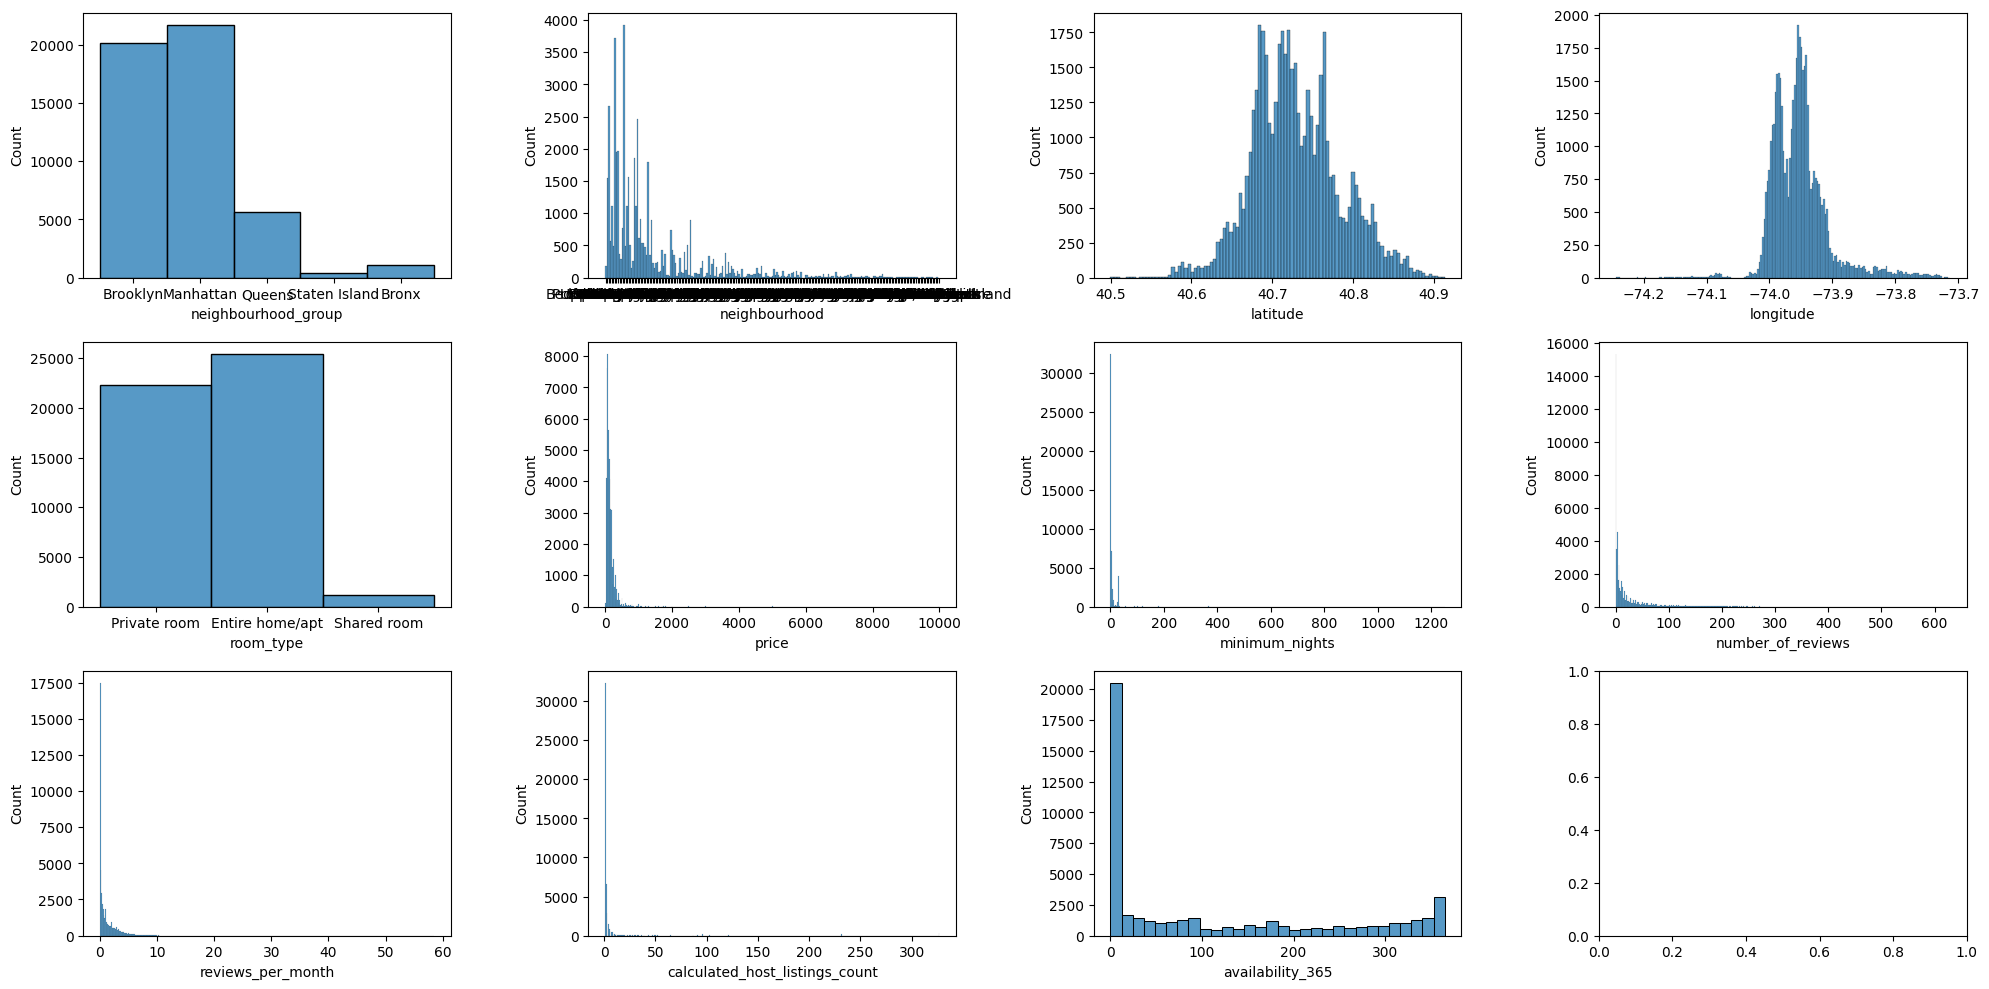

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axis = plt.subplots(3, 4, figsize=(20, 10))

sns.histplot(data=data, x='neighbourhood_group', ax=axis[0,0])
sns.histplot(data=data, x='neighbourhood', ax=axis[0,1])
sns.histplot(data=data, x='latitude', ax=axis[0,2])
sns.histplot(data=data, x='longitude', ax=axis[0,3])

sns.histplot(data=data, x='room_type', ax=axis[1,0])
sns.histplot(data=data, x='price', ax=axis[1,1])
sns.histplot(data=data, x='minimum_nights', ax=axis[1,2])
sns.histplot(data=data, x='number_of_reviews', ax=axis[1,3])

sns.histplot(data=data, x='reviews_per_month', ax=axis[2,0])
sns.histplot(data=data, x='calculated_host_listings_count', ax=axis[2,1])
sns.histplot(data=data, x='availability_365', ax=axis[2,2])

plt.tight_layout()
plt.show()

Se identificó que la mayor parte de los alojamientos se concentran en determinadas zonas geográficas y que el tipo de habitación más frecuente corresponde a viviendas completas.
Asimismo, la variable precio presenta una distribución asimétrica con presencia de valores extremos, mientras que variables como el número de reseñas y la disponibilidad muestran alta dispersión.

## Variables Numéricas

In [32]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  str    
 1   neighbourhood                   48895 non-null  str    
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  str    
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   reviews_per_month               48895 non-null  float64
 9   calculated_host_listings_count  48895 non-null  int64  
 10  availability_365                48895 non-null  int64  
dtypes: float64(3), int64(5), str(3)
memory usage: 4.1 MB


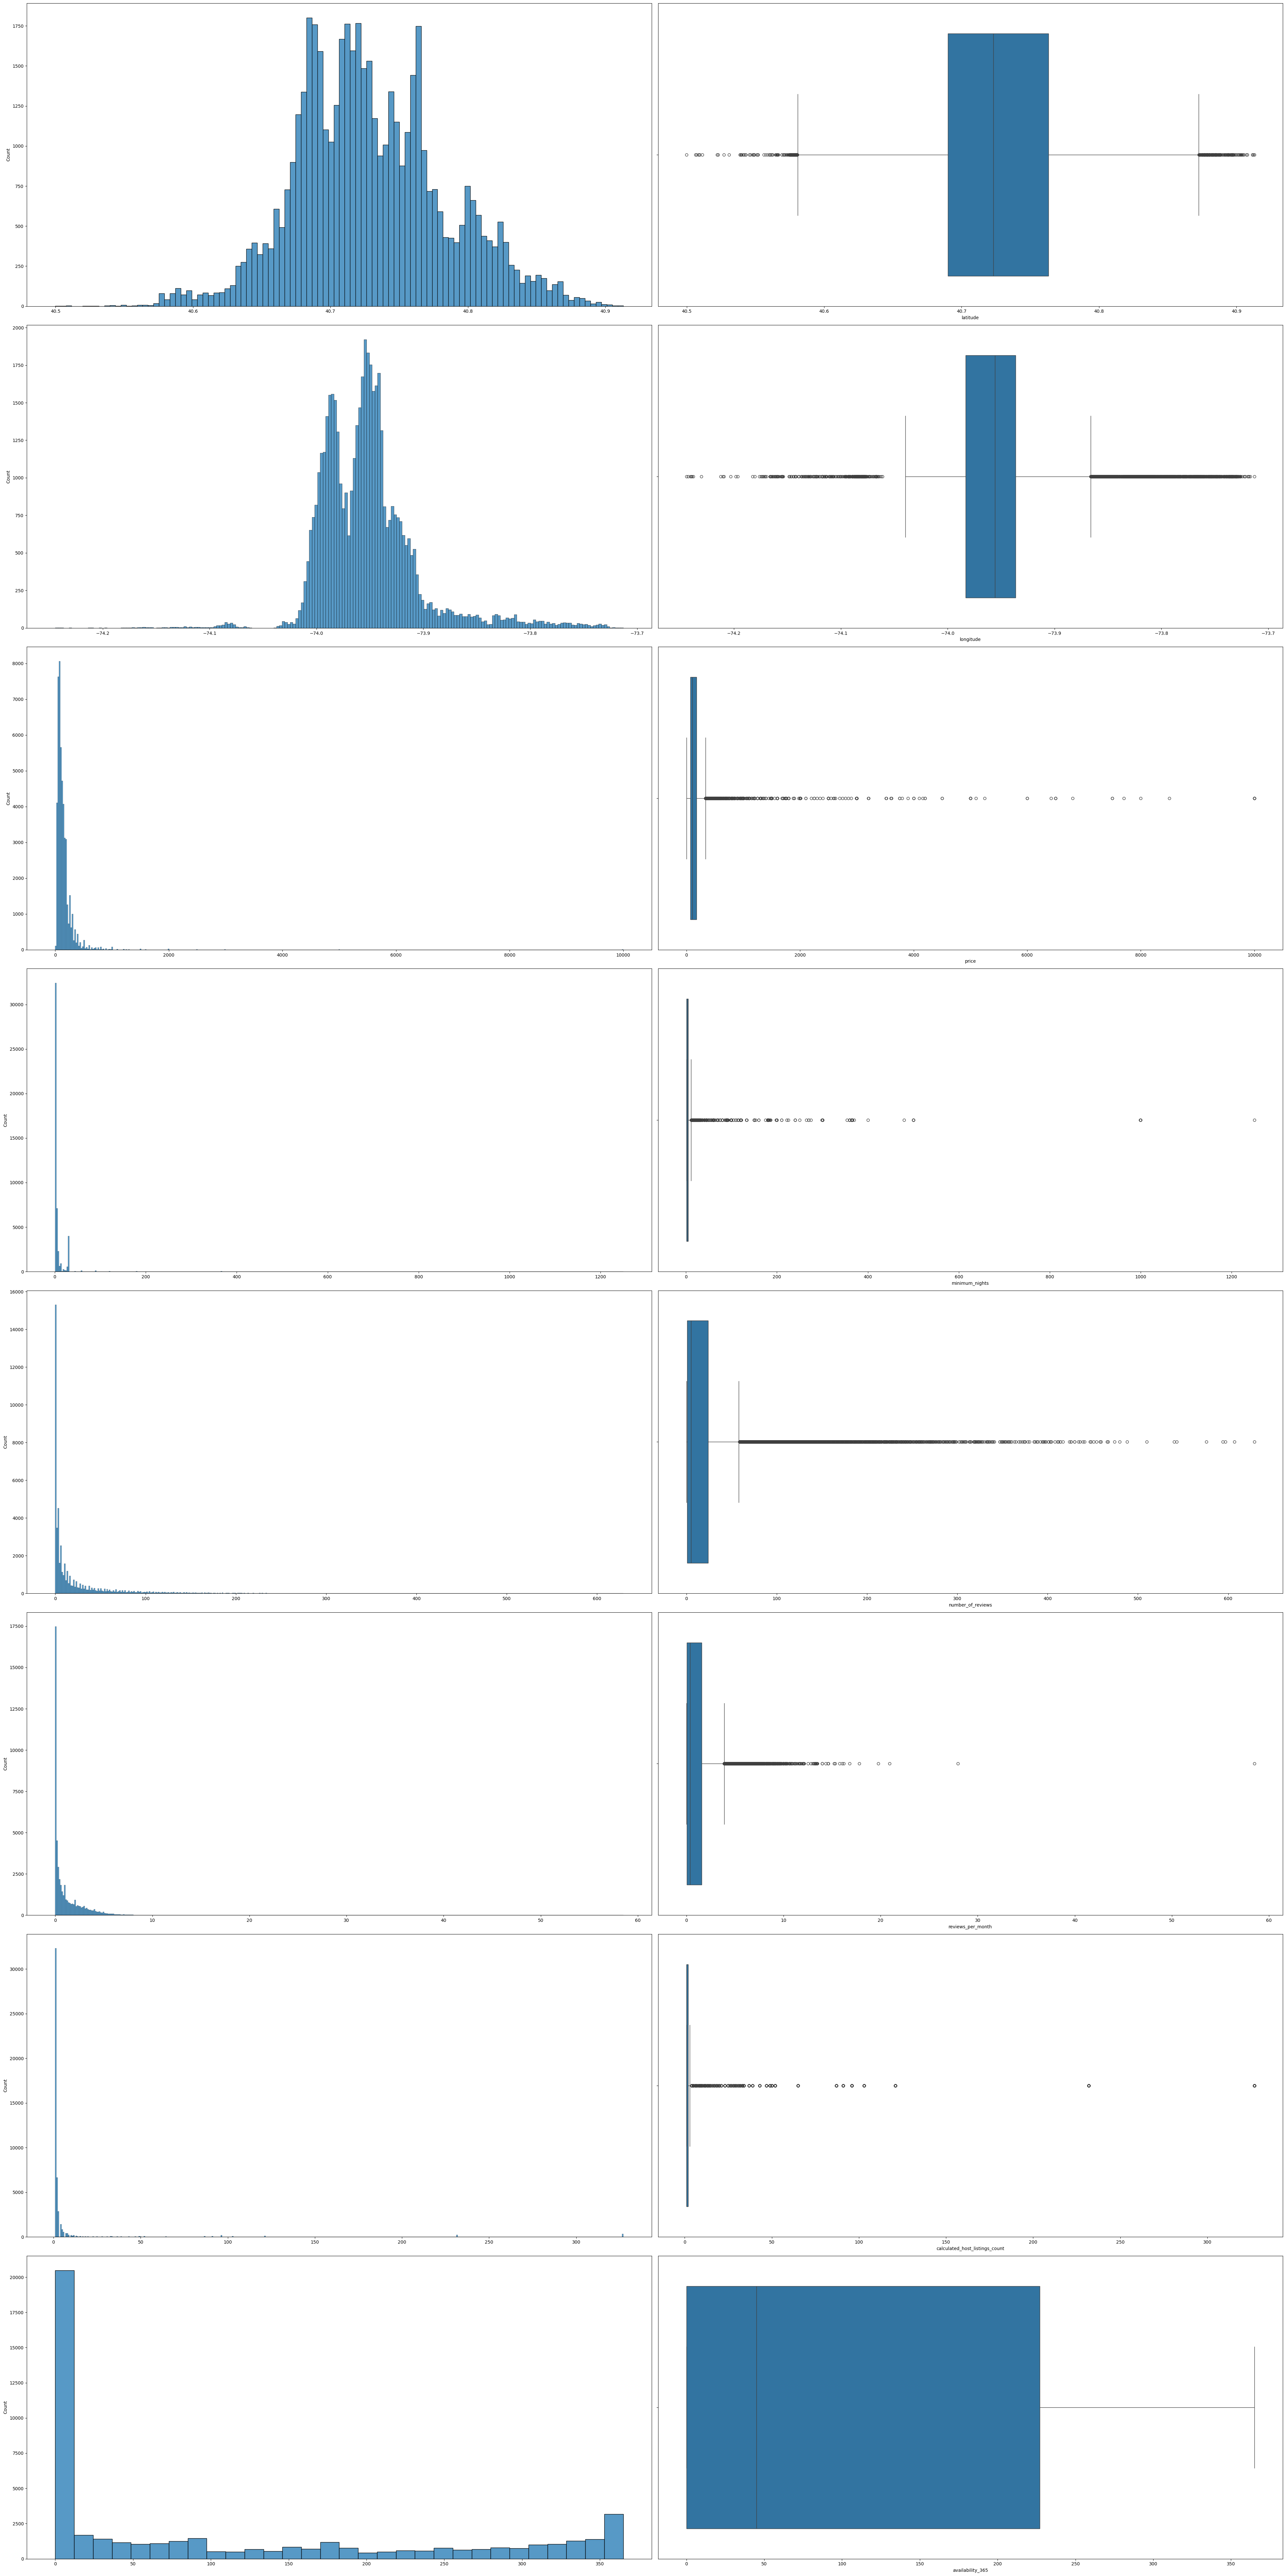

In [33]:
#GENERAMOS HISTOGRAMAS
import matplotlib.pyplot as plt
import seaborn as sns

fig, axis = plt.subplots(8, 2, figsize=(40, 80))

#CREAMOS UN DIAGRAMA DE DISPERSIÓN MÚLTIPLE
sns.histplot(ax=axis[0,0], data=data, x="latitude").set(xlabel = None)
sns.boxplot(ax=axis[0,1], data=data, x="latitude")
sns.histplot(ax=axis[1,0], data=data, x="longitude").set(xlabel = None)
sns.boxplot(ax=axis[1,1], data=data, x="longitude")
sns.histplot(ax=axis[2,0], data=data, x="price").set(xlabel = None)
sns.boxplot(ax=axis[2,1], data=data, x="price")
sns.histplot(ax=axis[3,0], data=data, x="minimum_nights").set(xlabel = None)
sns.boxplot(ax=axis[3,1], data=data, x="minimum_nights")
sns.histplot(ax=axis[4,0], data=data, x="number_of_reviews").set(xlabel = None)
sns.boxplot(ax=axis[4,1], data=data, x="number_of_reviews")
sns.histplot(ax=axis[5,0], data=data, x="reviews_per_month").set(xlabel = None)
sns.boxplot(ax=axis[5,1], data=data, x="reviews_per_month")
sns.histplot(ax=axis[6,0], data=data, x="calculated_host_listings_count").set(xlabel = None)
sns.boxplot(ax=axis[6,1], data=data, x="calculated_host_listings_count")
sns.histplot(ax=axis[7,0], data=data, x="availability_365").set(xlabel = None)
sns.boxplot(ax=axis[7,1], data=data, x="availability_365")

#AJUSTAR LAYAUT
plt.tight_layout()
#MOSTRAMOS EL PLOT
plt.show()

In [34]:
total_data["price"].describe()

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

### Conclusión variables numéricas general

Se observa que varias de las variables presentan distribuciones asimétricas y una alta concentración de valores en rangos específicos.

La variable precio muestra una fuerte presencia de valores extremos, lo que nos muestra la existencia de alojamientos considerablemente más costosos que la media.

De igual manera variables como lo son el número de reseñas y el número de noches mínimas presentan una concentración significativa en valores bajos, lo que sugiere que la mayoría de alojamientos recibe pocas evaluaciones y permite estancias cortas.

Por otro lado, la disponibilidad anual y la cantidad de alojamientos gestionados por anfitrión muestran una alta dispersión, evidenciando diferentes estrategias de oferta dentro del mercado.

Estos resultados permiten identificar patrones relevantes en el comportamiento de las variables numéricas y facilitan la detección de posibles valores atípicos que deberán considerarse en etapas posteriores del análisis o modelado.

### Conclusión outliers
A partir del análisis mediante diagramas de caja se identificó la presencia de valores atípicos especialmente en el precio y en el número mínimo de noches.

Estos valores extremos representan alojamientos con características particulares, como precios significativamente elevados o condiciones de estancia poco comunes.

### Conclusión variable precio (la más relevante)
La variable precio presenta una fuerte inclinación hacia la derecha, lo que indica que la mayoría de los alojamientos se concentran en rangos de precio bajos o moderados.

Sin embargo, se observan valores extremadamente altos que generan una amplia dispersión en los datos.
Este comportamiento sugiere la existencia de diferentes segmentos dentro del mercado de alojamientos, desde opciones económicas hasta propiedades de lujo.

## Análisis multivariante

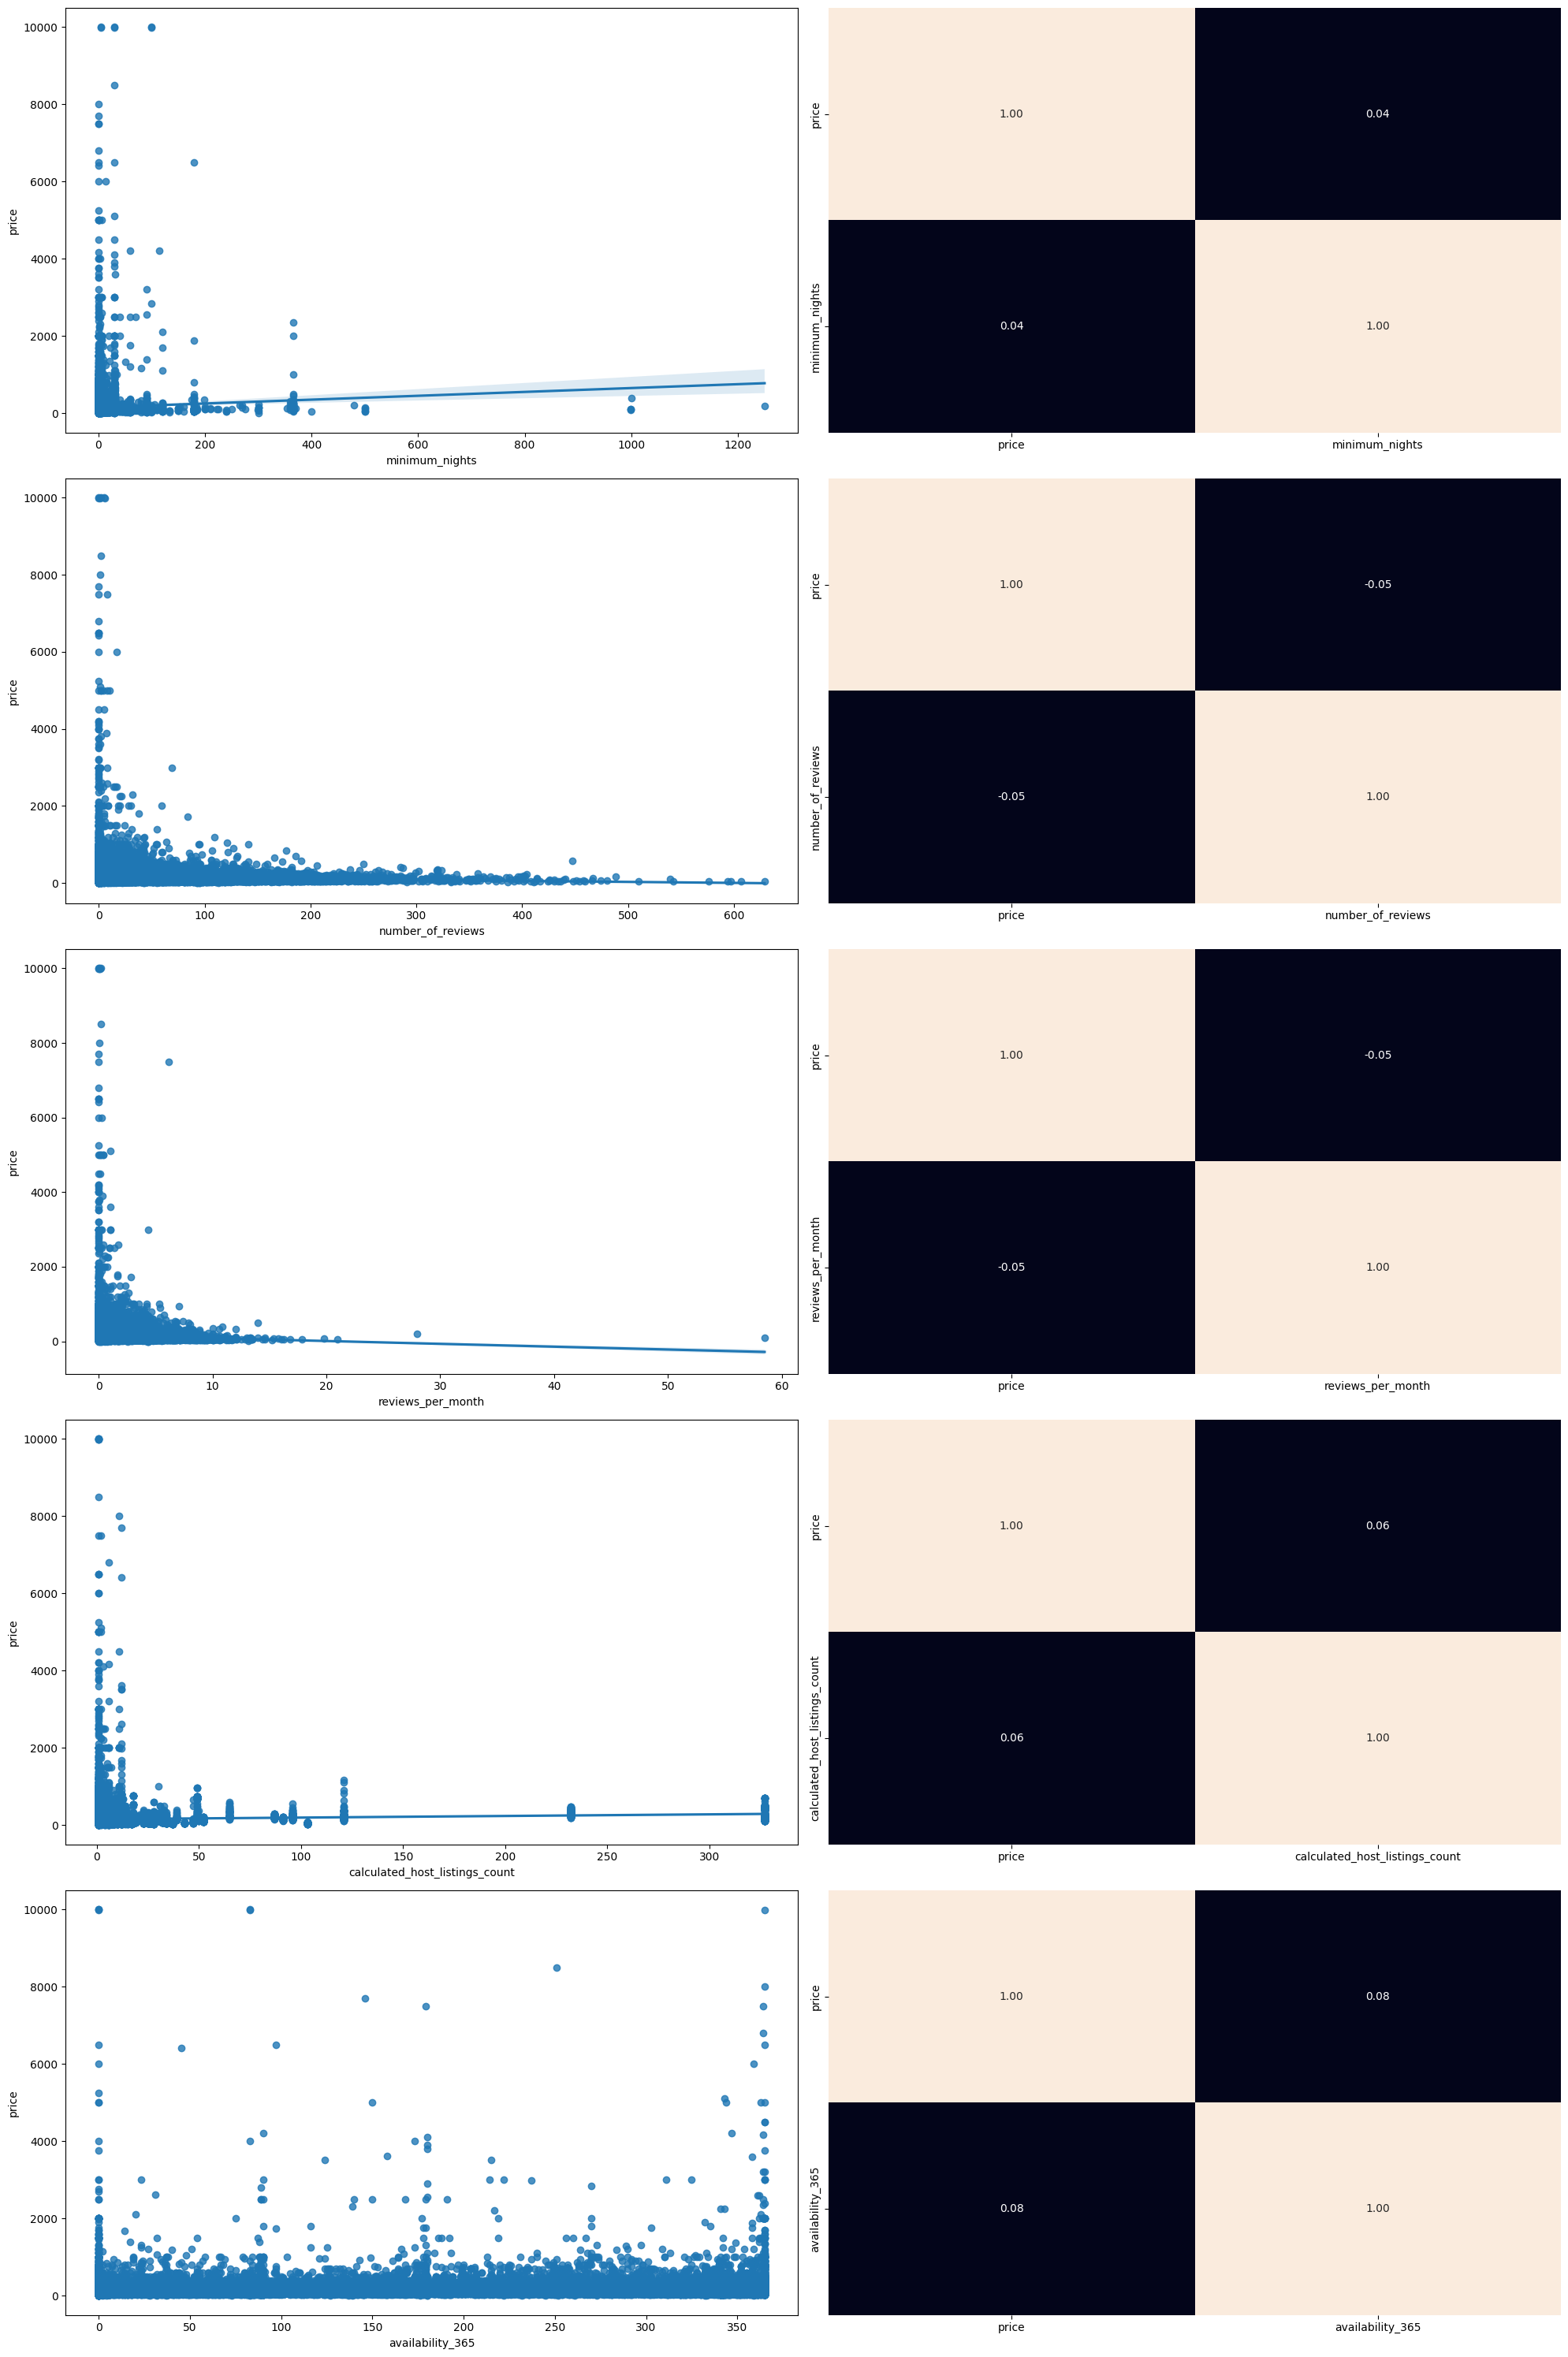

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axis = plt.subplots(5, 2, figsize=(20, 30))

sns.regplot(ax=axis[0,0], data=total_data, x="minimum_nights", y="price")
sns.heatmap(total_data[["price", "minimum_nights"]].corr(),
            annot=True, fmt=".2f", ax=axis[0,1], cbar=False)

sns.regplot(ax=axis[1,0], data=total_data, x="number_of_reviews", y="price")
sns.heatmap(total_data[["price", "number_of_reviews"]].corr(),
            annot=True, fmt=".2f", ax=axis[1,1], cbar=False)

sns.regplot(ax=axis[2,0], data=total_data, x="reviews_per_month", y="price")
sns.heatmap(total_data[["price", "reviews_per_month"]].corr(),
            annot=True, fmt=".2f", ax=axis[2,1], cbar=False)

sns.regplot(ax=axis[3,0], data=total_data, x="calculated_host_listings_count", y="price")
sns.heatmap(total_data[["price", "calculated_host_listings_count"]].corr(),
            annot=True, fmt=".2f", ax=axis[3,1], cbar=False)

sns.regplot(ax=axis[4,0], data=total_data, x="availability_365", y="price")
sns.heatmap(total_data[["price", "availability_365"]].corr(),
            annot=True, fmt=".2f", ax=axis[4,1], cbar=False)


plt.tight_layout()
plt.show()

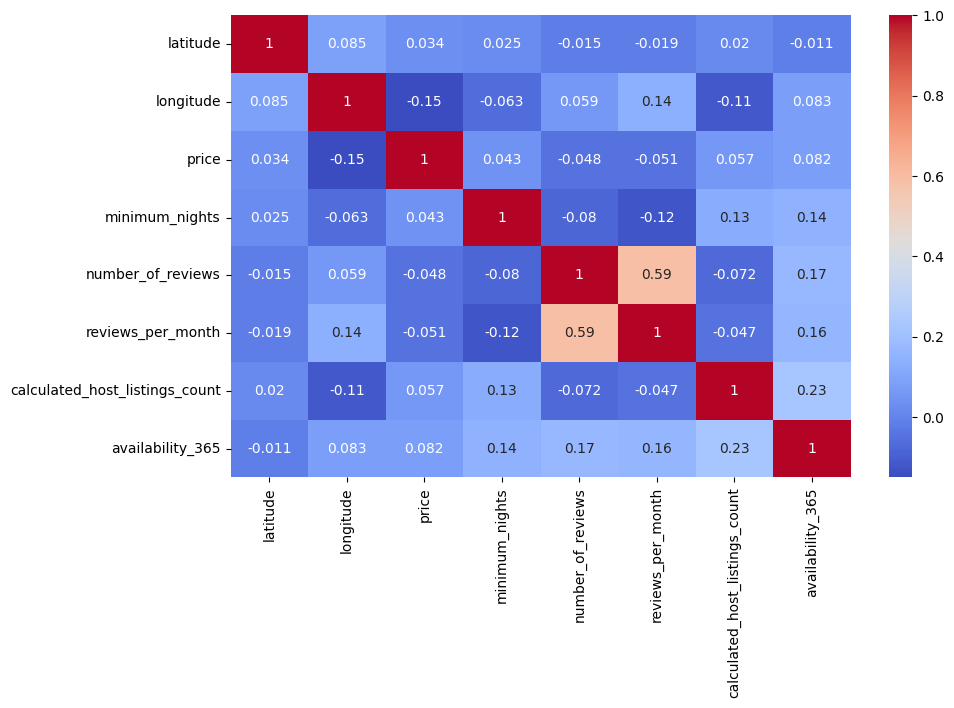

In [43]:
corr = data.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

Las gráficas de dispersión nos muestran una alta variabilidad en los precios independientemente de los valores de las variables analizadas, lo que nos confirma los coeficientes de correlación bajos que vemos en el headmap.
Esto sugiere que el precio de los alojamientos depende de múltiples factores y no puede ser explicado únicamente por una variable numérica.

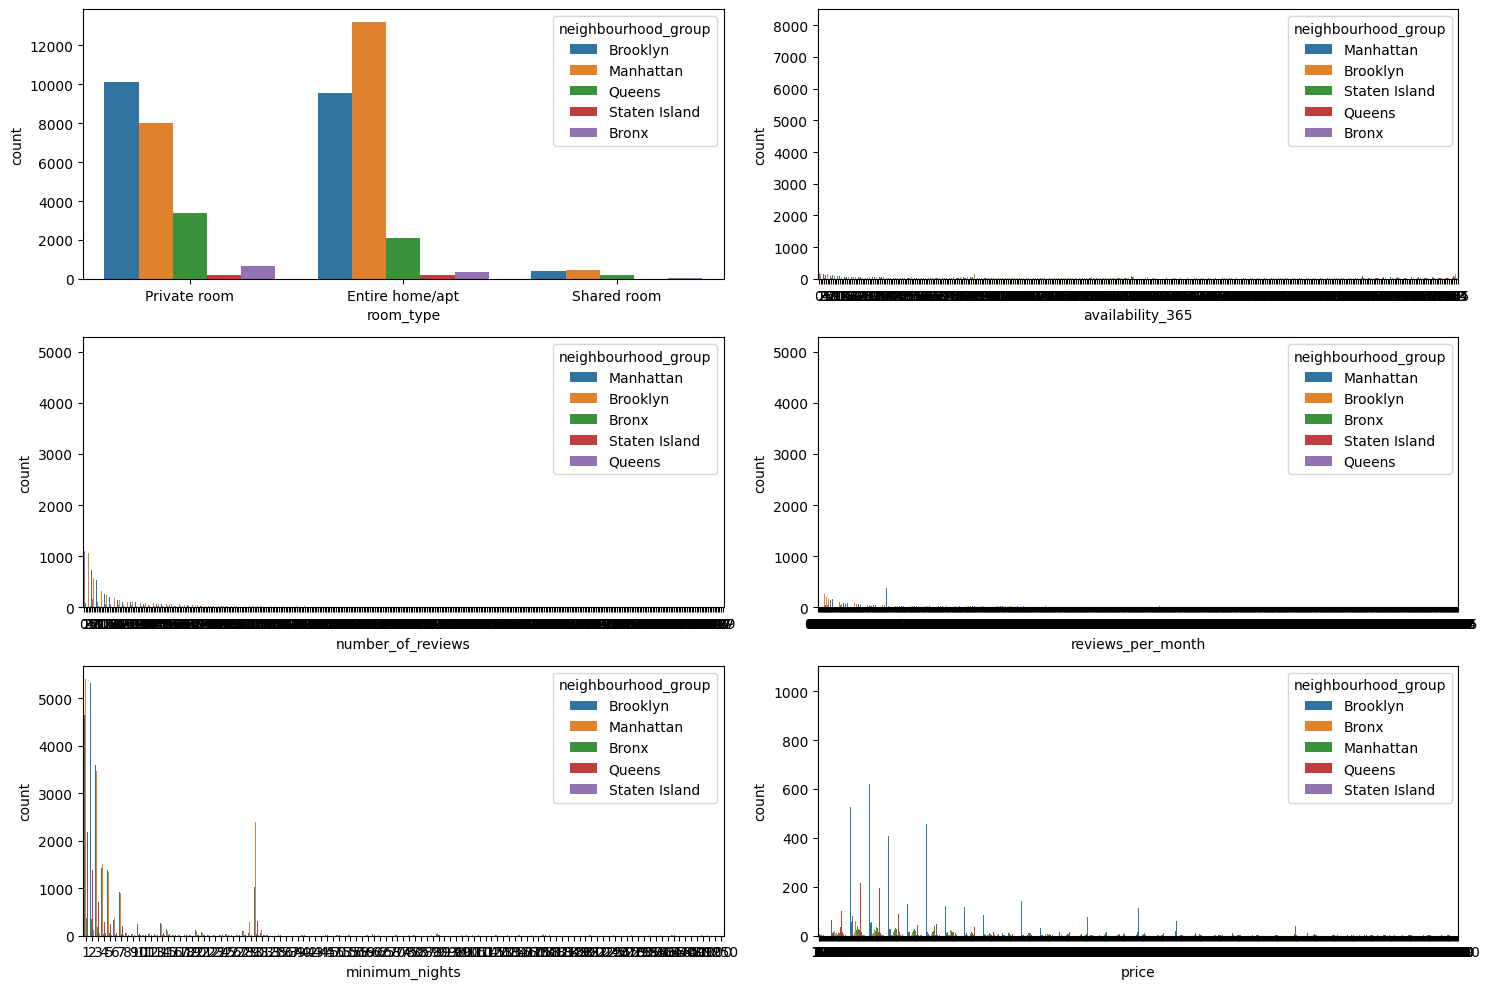

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axis = plt.subplots(3, 2, figsize=(15, 10))
sns.countplot(ax=axis[0,0],x="room_type", hue="neighbourhood_group", data=data)
sns.countplot(ax=axis[0,1],x="availability_365", hue="neighbourhood_group", data=data)
sns.countplot(ax=axis[1,0],x="number_of_reviews", hue="neighbourhood_group", data=data)
sns.countplot(ax=axis[1,1],x="reviews_per_month", hue="neighbourhood_group", data=data)
sns.countplot(ax=axis[2,0],x="minimum_nights", hue="neighbourhood_group", data=data)
sns.countplot(ax=axis[2,1],x="price", hue="neighbourhood_group", data=data)

plt.tight_layout()
plt.show()

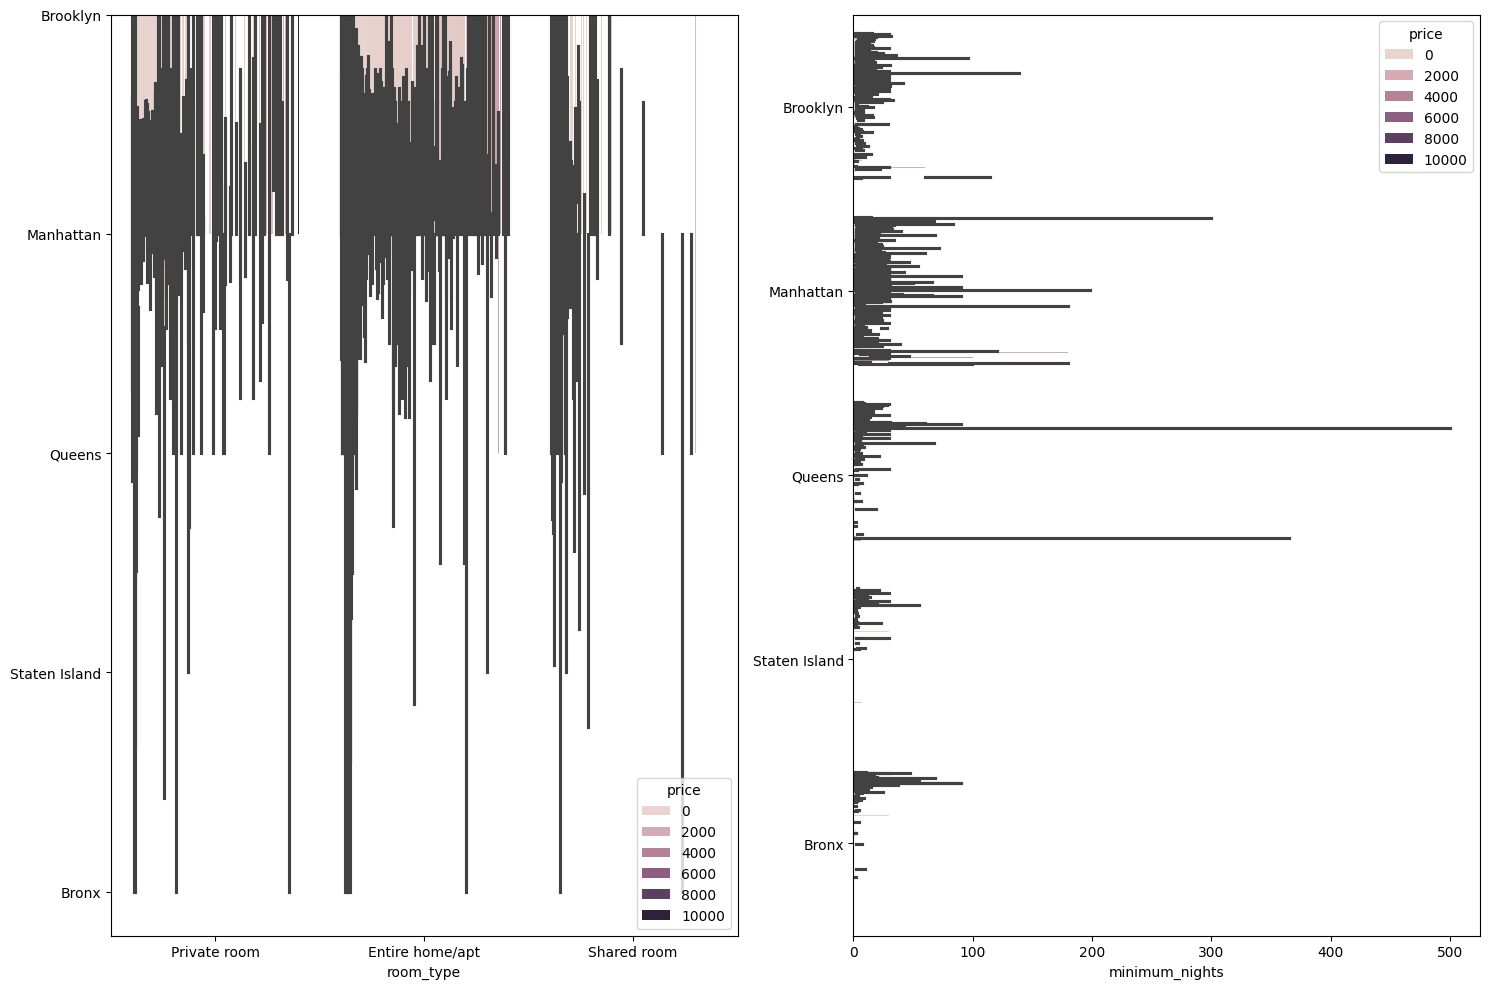

In [48]:
fig, axis = plt.subplots(ncols=2, figsize=(15, 10))
sns.barplot(ax=axis[0],data=total_data, x= "room_type", y="neighbourhood_group",hue="price").set(ylabel=None)
sns.barplot(ax=axis[1],data=total_data, x= "minimum_nights", y="neighbourhood_group",hue="price").set(ylabel=None)

plt.tight_layout()
plt.show()